In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [6]:
DATASET_PATH = "CXR_dataset/train"

In [7]:
class_counts = {}

for class_name in os.listdir(DATASET_PATH):
    
    class_path = os.path.join(DATASET_PATH, class_name)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        class_counts[class_name] = len(images)

print(class_counts)

{'NORMAL': 1108, 'PNEUMONIA': 2991}


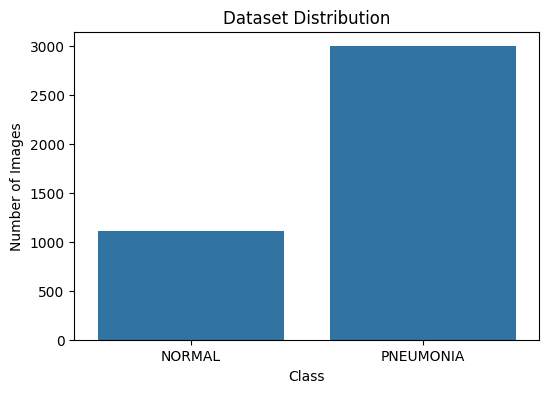

In [8]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

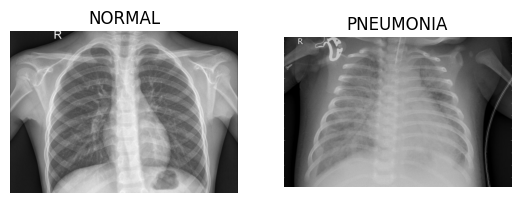

In [9]:
plt.figure(figsize=(10,5))

i = 1

for class_name in os.listdir(DATASET_PATH):
    
    class_path = os.path.join(DATASET_PATH, class_name)
    
    if os.path.isdir(class_path):
        
        image_name = os.listdir(class_path)[0]
        img_path = os.path.join(class_path, image_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,3,i)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        i += 1

plt.show()

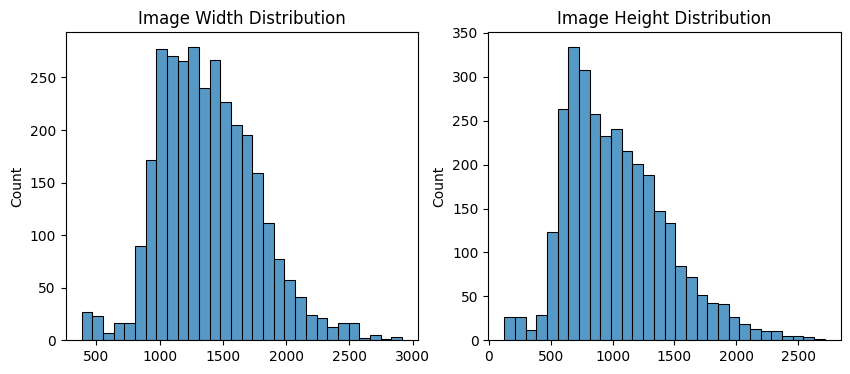

In [11]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(widths, bins=30)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30)
plt.title("Image Height Distribution")

plt.show()

In [12]:
print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 1387.1181556195966
Average height: 1033.5203330131285


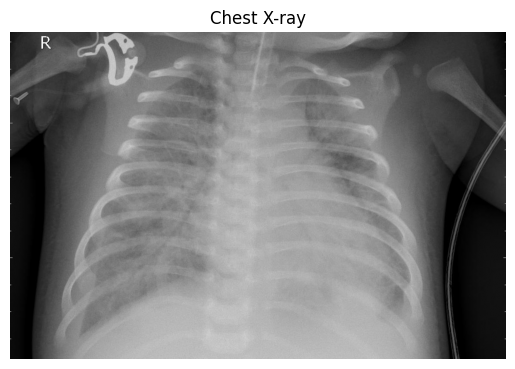

Min pixel value: 0
Max pixel value: 255
Mean pixel value: 114.53725328947368


In [14]:
DATASET_PATH = "CXR_dataset/train/PNEUMONIA"

image_name = os.listdir(DATASET_PATH)[0]
img_path = os.path.join(DATASET_PATH, image_name)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Chest X-ray")
plt.axis("off")
plt.show()

print("Min pixel value:", np.min(img))
print("Max pixel value:", np.max(img))
print("Mean pixel value:", np.mean(img))

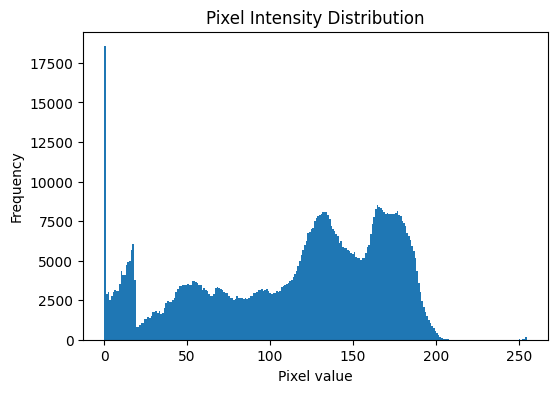

In [15]:
plt.figure(figsize=(6,4))

plt.hist(img.ravel(), bins=256)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")

plt.show()

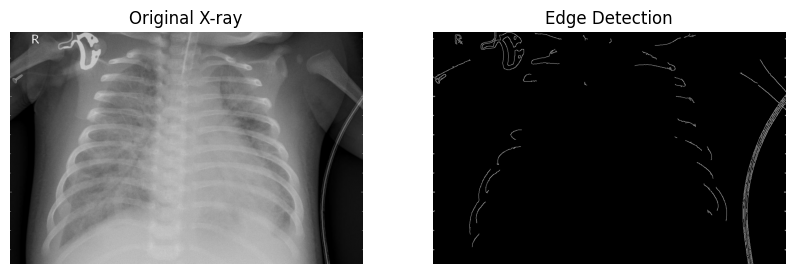

In [16]:
edges = cv2.Canny(img, 50, 150)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")

plt.show()

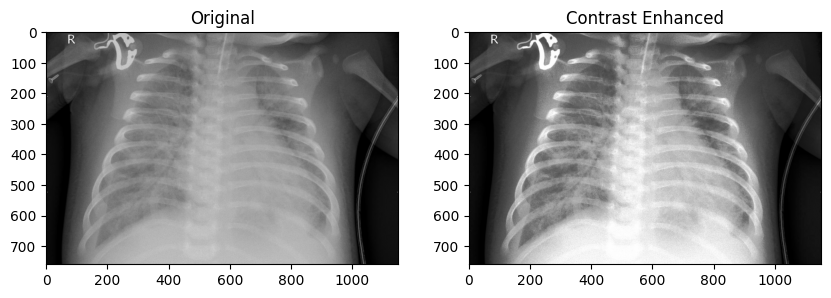

In [17]:
equalized = cv2.equalizeHist(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap="gray")
plt.title("Contrast Enhanced")

plt.show()

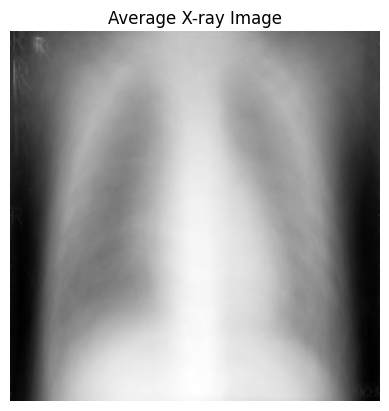

In [18]:
images = []

for img_name in os.listdir(DATASET_PATH)[:100]:
    
    path = os.path.join(DATASET_PATH, img_name)
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224,224))
    
    images.append(img)

avg_img = np.mean(images, axis=0)

plt.imshow(avg_img, cmap="gray")
plt.title("Average X-ray Image")
plt.axis("off")
plt.show()

In [2]:
import os

base_path = "CXR_dataset"

splits = ["train", "val", "test"]

for split in splits:
    
    print("\n", split.upper())
    
    split_path = os.path.join(base_path, split)
    
    for cls in os.listdir(split_path):
        
        class_path = os.path.join(split_path, cls)
        
        count = len(os.listdir(class_path))
        
        print(cls, ":", count)


 TRAIN
NORMAL : 1108
PNEUMONIA : 2991

 VAL
NORMAL : 237
PNEUMONIA : 641

 TEST
NORMAL : 238
PNEUMONIA : 641


In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
base_path = "CXR_dataset"

splits = ["train","val","test"]

data = []

for split in splits:

    split_path = os.path.join(base_path, split)

    for cls in os.listdir(split_path):

        class_path = os.path.join(split_path, cls)

        count = len(os.listdir(class_path))

        data.append({
            "split": split,
            "class": cls,
            "count": count
        })

df = pd.DataFrame(data)

df

,split,class,count
0,train,NORMAL,1108
1,train,PNEUMONIA,2991
2,val,NORMAL,237
3,val,PNEUMONIA,641
4,test,NORMAL,238
5,test,PNEUMONIA,641


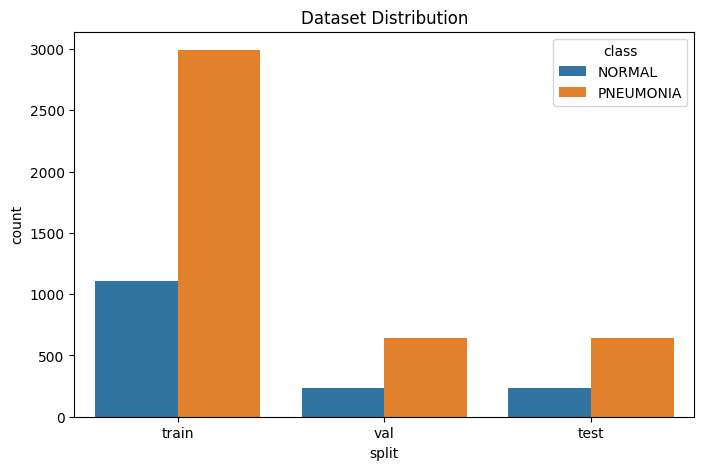

In [5]:
#dataset distribution :
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="split",
    y="count",
    hue="class"
)

plt.title("Dataset Distribution")

plt.show()

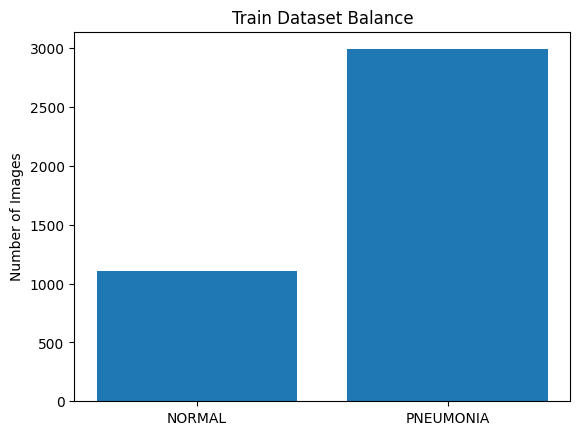

In [7]:
#class balance
train_path = "CXR_dataset/train"

labels = []
counts = []

for cls in os.listdir(train_path):

    labels.append(cls)

    counts.append(
        len(os.listdir(os.path.join(train_path,cls)))
    )

plt.bar(labels, counts)

plt.title("Train Dataset Balance")

plt.ylabel("Number of Images")

plt.show()

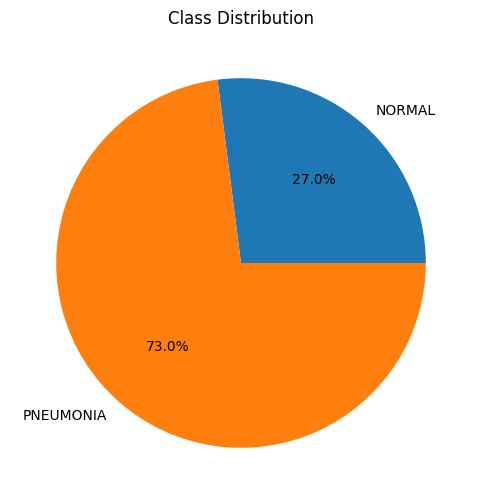

In [8]:
plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Class Distribution")

plt.show()